In [8]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

SIGNATURE_FILES = [
    "COO-Matrix/CIBERSORTx-Matrix_TSP-BDa_Inner_1000_3000_10/CIBERSORTx_TSP-BDa_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Inner_25each_inferred_refsample.bm.K999.txt",
    "COO-Matrix/CIBERSORTx-Matrix_TSP-BDa_Inner_3000_5000_10/CIBERSORTx_TSP-BDa_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Inner_25each_inferred_refsample.bm.K999.txt",
    "COO-Matrix/CIBERSORTx-Matrix_TSP-BDa_Inner_300_1500_10/CIBERSORTx_TSP-BDa_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Inner_25each_inferred_refsample.bm.K999.txt",
    "COO-Matrix/CIBERSORTx-Matrix_TSP-BDa_Outer_1000_3000_10/CIBERSORTx_TSP-BDa_Outer_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Outer_25each_inferred_refsample.bm.K999.txt",
    "COO-Matrix/CIBERSORTx-Matrix_TSP-BDa_Outer_3000_5000_10/CIBERSORTx_TSP-BDa_Outer_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Outer_25each_inferred_refsample.bm.K999.txt",
    "COO-Matrix/CIBERSORTx-Matrix_TSP-BDa_Outer_300_1500_10/CIBERSORTx_TSP-BDa_Outer_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Outer_25each_inferred_refsample.bm.K999.txt",
    "COO-Matrix/CIBERSORTx-Matrix_TSP-HBA_Inner_1000_3000_10/CIBERSORTx_TSP-HBA_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-HBA_Inner_25each_inferred_refsample.bm.K999.txt",
    "COO-Matrix/CIBERSORTx-Matrix_TSP-HBA_Inner_3000_5000_10/CIBERSORTx_TSP-HBA_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-HBA_Inner_25each_inferred_refsample.bm.K999.txt",
    "COO-Matrix/CIBERSORTx-Matrix_TSP-HBA_Inner_300_1500_10/CIBERSORTx_TSP-HBA_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-HBA_Inner_25each_inferred_refsample.bm.K999.txt",
]

OUTDIR = "Matrix-Similarity/COO_Matrices_Cosine_Similarity"
LOG1P = False

os.makedirs(OUTDIR, exist_ok=True)

def safe_name(path):
    parent = os.path.basename(os.path.dirname(path))
    base = os.path.basename(path).replace(".txt", "")
    return f"{parent}__{base}"


def read_signature_matrix(path, log1p=True):
    df = pd.read_csv(path, sep="\t")

    if "NAME" not in df.columns:
        raise ValueError(f"'NAME' column not found in {path}")

    df = df.set_index("NAME")
    df = df.apply(pd.to_numeric, errors="coerce")

    if df.isna().any().any():
        n_na = int(df.isna().sum().sum())
        raise ValueError(f"{path} contains {n_na} non-numeric/NA values")

    if log1p:
        df = np.log1p(df)

    return df


def cosine_by_cell_type(df):
    sim = cosine_similarity(df.T)

    return pd.DataFrame(
        sim,
        index=df.columns,
        columns=df.columns
    )


def closest_match_summary(sim, matrix_name):
    sim_no_diag = sim.copy()
    np.fill_diagonal(sim_no_diag.values, np.nan)

    closest_cell_type = sim_no_diag.idxmax(axis=1)
    max_similarity = sim_no_diag.max(axis=1)

    summary = pd.DataFrame({
        "matrix": matrix_name,
        "cell_type": sim.index,
        "closest_match": closest_cell_type.values,
        "max_cosine_similarity": max_similarity.values,
        "mean_cosine_similarity": sim_no_diag.mean(axis=1).values,
        "n_cell_types_with_cosine_gt_0.90": (sim_no_diag > 0.90).sum(axis=1).values,
        "n_cell_types_with_cosine_gt_0.95": (sim_no_diag > 0.95).sum(axis=1).values,
        "n_cell_types_with_cosine_gt_0.98": (sim_no_diag > 0.98).sum(axis=1).values,
    })

    return summary.sort_values("max_cosine_similarity", ascending=False)


all_summaries = []
all_similarity_matrices = {}

for path in SIGNATURE_FILES:
    if not os.path.exists(path):
        print(f"WARNING: file not found, skipping: {path}")
        continue

    matrix_name = safe_name(path)
    print(f"Processing: {matrix_name}")

    df = read_signature_matrix(path, log1p=LOG1P)
    sim = cosine_by_cell_type(df)
    summary = closest_match_summary(sim, matrix_name)

    all_similarity_matrices[matrix_name] = sim
    all_summaries.append(summary)

    sim.to_csv(
        os.path.join(OUTDIR, f"{matrix_name}.cosine_similarity.tsv"),
        sep="\t"
    )

    summary.to_csv(
        os.path.join(OUTDIR, f"{matrix_name}.closest_matches.tsv"),
        sep="\t",
        index=False
    )

combined_summary = pd.concat(all_summaries, ignore_index=True)

combined_summary.to_csv(
    os.path.join(OUTDIR, "ALL_matrices.closest_matches.tsv"),
    sep="\t",
    index=False
)

combined_summary

Processing: CIBERSORTx-Matrix_TSP-BDa_Inner_1000_3000_10__CIBERSORTx_TSP-BDa_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Inner_25each_inferred_refsample.bm.K999
Processing: CIBERSORTx-Matrix_TSP-BDa_Inner_3000_5000_10__CIBERSORTx_TSP-BDa_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Inner_25each_inferred_refsample.bm.K999
Processing: CIBERSORTx-Matrix_TSP-BDa_Inner_300_1500_10__CIBERSORTx_TSP-BDa_Inner_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Inner_25each_inferred_refsample.bm.K999
Processing: CIBERSORTx-Matrix_TSP-BDa_Outer_1000_3000_10__CIBERSORTx_TSP-BDa_Outer_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Outer_25each_inferred_refsample.bm.K999
Processing: CIBERSORTx-Matrix_TSP-BDa_Outer_3000_5000_10__CIBERSORTx_TSP-BDa_Outer_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Outer_25each_inferred_refsample.bm.K999
Processing: CIBERSORTx-Matrix_TSP-BDa_Outer_300_1500_10__CIBERSORTx_TSP-BDa_Outer_25each_inferred_phenoclasses.CIBERSORTx_TSP-BDa_Outer_25each_inf

,matrix,cell_type,closest_match,max_cosine_similarity,mean_cosine_similarity,n_cell_types_with_cosine_gt_0.90,n_cell_types_with_cosine_gt_0.95,n_cell_types_with_cosine_gt_0.98
0,CIBERSORTx-Matrix_TSP-BDa_Inner_1000_3000_10__...,"cd4-positive, alpha-beta t cell/naive thymus-d...","cd4-positive, alpha-beta thymocyte",0.987865,0.471002,6,1,1
1,CIBERSORTx-Matrix_TSP-BDa_Inner_1000_3000_10__...,"cd4-positive, alpha-beta thymocyte","cd4-positive, alpha-beta t cell/naive thymus-d...",0.987865,0.459764,6,1,1
2,CIBERSORTx-Matrix_TSP-BDa_Inner_1000_3000_10__...,"cd8-positive, alpha-beta thymocyte/thymocyte","cd4-positive, alpha-beta t cell/naive thymus-d...",0.944111,0.464488,3,0,0
3,CIBERSORTx-Matrix_TSP-BDa_Inner_1000_3000_10__...,"activated cd4-positive, alpha-beta t cell/acti...","cd4-positive, alpha-beta t cell/naive thymus-d...",0.943801,0.473805,4,0,0
4,CIBERSORTx-Matrix_TSP-BDa_Inner_1000_3000_10__...,"cd8-positive, alpha-beta t cell/naive thymus-d...","cd4-positive, alpha-beta t cell/naive thymus-d...",0.942134,0.473642,6,0,0
...,...,...,...,...,...,...,...,...
676,CIBERSORTx-Matrix_TSP-HBA_Inner_300_1500_10__C...,type ii pneumocyte,basal cell/medullary thymic epithelial cell,0.280105,0.155950,0,0,0
677,CIBERSORTx-Matrix_TSP-HBA_Inner_300_1500_10__C...,fast muscle cell/slow muscle cell,myo-medullary thymic epithelial cell,0.235566,0.094895,0,0,0
678,CIBERSORTx-Matrix_TSP-HBA_Inner_300_1500_10__C...,acinar cell of salivary gland,duct epithelial cell/ionocyte/mucus secreting ...,0.193516,0.058539,0,0,0
679,CIBERSORTx-Matrix_TSP-HBA_Inner_300_1500_10__C...,pancreatic d cell/type b pancreatic cell,serous cell of epithelium of trachea,0.118263,0.057505,0,0,0


In [9]:
def matrix_collinearity_metrics(sim, df, matrix_name):

    vals = sim.values[np.triu_indices_from(sim, k=1)]

    return pd.DataFrame({
        "matrix": [matrix_name],
        "mean_cosine": [vals.mean()],
        "median_cosine": [np.median(vals)],
        "p95_cosine": [np.percentile(vals, 95)],
        "max_cosine": [vals.max()],
        "condition_number": [np.linalg.cond(df.values)]
    })


# ---------------------------------------------------
# Compute overall matrix-level collinearity summaries
# ---------------------------------------------------

matrix_metrics = []

for path in SIGNATURE_FILES:

    if not os.path.exists(path):
        continue

    matrix_name = safe_name(path)

    df = read_signature_matrix(path, log1p=LOG1P)

    sim = cosine_by_cell_type(df)

    metrics = matrix_collinearity_metrics(
        sim=sim,
        df=df,
        matrix_name=matrix_name
    )

    matrix_metrics.append(metrics)

matrix_metrics_df = pd.concat(matrix_metrics, ignore_index=True)

# Save
matrix_metrics_df.to_csv(
    os.path.join(
        OUTDIR,
        "COO_matrices.collinearity_metrics.tsv"
    ),
    sep="\t",
    index=False
)

# Pretty display
matrix_metrics_df = matrix_metrics_df.sort_values(
    "median_cosine",
    ascending=False
)

matrix_metrics_df

,matrix,mean_cosine,median_cosine,p95_cosine,max_cosine,condition_number
1,CIBERSORTx-Matrix_TSP-BDa_Inner_3000_5000_10__...,0.506729,0.553515,0.867746,0.990378,115.857851
4,CIBERSORTx-Matrix_TSP-BDa_Outer_3000_5000_10__...,0.405061,0.426555,0.773304,0.973530,118.721251
3,CIBERSORTx-Matrix_TSP-BDa_Outer_1000_3000_10__...,0.404140,0.426022,0.773480,0.973624,119.317819
5,CIBERSORTx-Matrix_TSP-BDa_Outer_300_1500_10__C...,0.393610,0.414970,0.769486,0.972609,125.548565
0,CIBERSORTx-Matrix_TSP-BDa_Inner_1000_3000_10__...,0.317495,0.285233,0.692782,0.987865,114.016140
7,CIBERSORTx-Matrix_TSP-HBA_Inner_3000_5000_10__...,0.347402,0.285158,0.760864,0.967263,111.192299
6,CIBERSORTx-Matrix_TSP-HBA_Inner_1000_3000_10__...,0.347067,0.284576,0.760796,0.967312,111.457578
2,CIBERSORTx-Matrix_TSP-BDa_Inner_300_1500_10__C...,0.314952,0.281123,0.692152,0.988048,115.447242
8,CIBERSORTx-Matrix_TSP-HBA_Inner_300_1500_10__C...,0.329290,0.263585,0.746776,0.968725,120.499642


In [10]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

SIGNATURE_FILES = [
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_2Median_1000_1500/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_2Median.CIBERSORTx_20250405_GeneID_LessTissueV2_2Median.withGTFNames.txt",
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_2Median_300_500/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_2Median.CIBERSORTx_20250405_GeneID_LessTissueV2_2Median.withGTFNames.txt",
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_2Median_500_1000/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_2Median.CIBERSORTx_20250405_GeneID_LessTissueV2_2Median.withGTFNames.txt",
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_Sampling10_1000_1500/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling10.CIBERSORTx_20250405_GeneID_LessTissueV2_Sampling10.withGTFNames.txt",
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_Sampling10_300_500/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling10.CIBERSORTx_20250405_GeneID_LessTissueV2_Sampling10.withGTFNames.txt",
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_Sampling10_500_1000/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling10.CIBERSORTx_20250405_GeneID_LessTissueV2_Sampling10.withGTFNames.txt",
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_Sampling5_1000_1500/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling5.CIBERSORTx_20250405_GeneID_LessTissueV2_Sampling5.withGTFNames.txt",
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_Sampling5_300_500/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling5.CIBERSORTx_20250405_GeneID_LessTissueV2_Sampling5.withGTFNames.txt",
    "TOO-Matrix/TOO-Matrices_Renamed/CIBERSORTx-TOO-Matrix_Sampling5_500_1000/CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling5.CIBERSORTx_20250405_GeneID_LessTissueV2_Sampling5.withGTFNames.txt",
]

# Separate output folder
OUTDIR = "Matrix-Similarity/TOO_Matrices_Cosine_Similarity"
os.makedirs(OUTDIR, exist_ok=True)
LOG1P = False

all_summaries = []
all_similarity_matrices = {}

for path in SIGNATURE_FILES:
    if not os.path.exists(path):
        print(f"WARNING: file not found, skipping: {path}")
        continue

    matrix_name = safe_name(path)
    print(f"Processing: {matrix_name}")

    df = read_signature_matrix(path, log1p=LOG1P)
    sim = cosine_by_cell_type(df)
    summary = closest_match_summary(sim, matrix_name)

    all_similarity_matrices[matrix_name] = sim
    all_summaries.append(summary)

    sim.to_csv(
        os.path.join(OUTDIR, f"{matrix_name}.cosine_similarity.tsv"),
        sep="\t"
    )

    summary.to_csv(
        os.path.join(OUTDIR, f"{matrix_name}.closest_matches.tsv"),
        sep="\t",
        index=False
    )

combined_summary = pd.concat(all_summaries, ignore_index=True)

combined_summary.to_csv(
    os.path.join(OUTDIR, "ALL_matrices.closest_matches.tsv"),
    sep="\t",
    index=False
)

combined_summary

Processing: CIBERSORTx-TOO-Matrix_2Median_1000_1500__CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_2Median.CIBERSORTx_20250405_GeneID_LessTissueV2_2Median.withGTFNames
Processing: CIBERSORTx-TOO-Matrix_2Median_300_500__CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_2Median.CIBERSORTx_20250405_GeneID_LessTissueV2_2Median.withGTFNames
Processing: CIBERSORTx-TOO-Matrix_2Median_500_1000__CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_2Median.CIBERSORTx_20250405_GeneID_LessTissueV2_2Median.withGTFNames
Processing: CIBERSORTx-TOO-Matrix_Sampling10_1000_1500__CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling10.CIBERSORTx_20250405_GeneID_LessTissueV2_Sampling10.withGTFNames
Processing: CIBERSORTx-TOO-Matrix_Sampling10_300_500__CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling10.CIBERSORTx_20250405_GeneID_LessTissueV2_Sampling10.withGTFNames
Processing: CIBERSORTx-TOO-Matrix_Sampling10_500_1000__CIBERSORTx_20250405_PhenotypeClass_LessTissueV2_Sampling10.CIBERSORTx_20250405_Gen

,matrix,cell_type,closest_match,max_cosine_similarity,mean_cosine_similarity,n_cell_types_with_cosine_gt_0.90,n_cell_types_with_cosine_gt_0.95,n_cell_types_with_cosine_gt_0.98
0,CIBERSORTx-TOO-Matrix_2Median_1000_1500__CIBER...,Esophagus,ColonSigmoid,0.984923,0.383467,2,1,1
1,CIBERSORTx-TOO-Matrix_2Median_1000_1500__CIBER...,ColonSigmoid,Esophagus,0.984923,0.368454,2,1,1
2,CIBERSORTx-TOO-Matrix_2Median_1000_1500__CIBER...,Adipose,Breast,0.976119,0.451402,1,1,0
3,CIBERSORTx-TOO-Matrix_2Median_1000_1500__CIBER...,Breast,Adipose,0.976119,0.477713,1,1,0
4,CIBERSORTx-TOO-Matrix_2Median_1000_1500__CIBER...,Brain,Kidney,0.960836,0.383906,1,1,0
...,...,...,...,...,...,...,...,...
265,CIBERSORTx-TOO-Matrix_Sampling5_500_1000__CIBE...,Fibroblasts,Arteries,0.527118,0.208323,0,0,0
266,CIBERSORTx-TOO-Matrix_Sampling5_500_1000__CIBE...,EsophagusMucosa,Skin,0.424208,0.310944,0,0,0
267,CIBERSORTx-TOO-Matrix_Sampling5_500_1000__CIBE...,Whole blood,Spleen,0.239275,0.099282,0,0,0
268,CIBERSORTx-TOO-Matrix_Sampling5_500_1000__CIBE...,Pituitary,Kidney,0.224996,0.166043,0,0,0


In [11]:
def matrix_collinearity_metrics(sim, df, matrix_name):

    vals = sim.values[np.triu_indices_from(sim, k=1)]

    return pd.DataFrame({
        "matrix": [matrix_name],
        "mean_cosine": [vals.mean()],
        "median_cosine": [np.median(vals)],
        "p95_cosine": [np.percentile(vals, 95)],
        "max_cosine": [vals.max()],
        "condition_number": [np.linalg.cond(df.values)]
    })


# ---------------------------------------------------
# Compute overall matrix-level collinearity summaries
# ---------------------------------------------------

matrix_metrics = []

for path in SIGNATURE_FILES:

    if not os.path.exists(path):
        continue

    matrix_name = safe_name(path)

    df = read_signature_matrix(path, log1p=LOG1P)

    sim = cosine_by_cell_type(df)

    metrics = matrix_collinearity_metrics(
        sim=sim,
        df=df,
        matrix_name=matrix_name
    )

    matrix_metrics.append(metrics)

matrix_metrics_df = pd.concat(matrix_metrics, ignore_index=True)

# Save
matrix_metrics_df.to_csv(
    os.path.join(
        OUTDIR,
        "TOO_matrices.collinearity_metrics.tsv"
    ),
    sep="\t",
    index=False
)

# Pretty display
matrix_metrics_df = matrix_metrics_df.sort_values(
    "median_cosine",
    ascending=False
)

matrix_metrics_df

,matrix,mean_cosine,median_cosine,p95_cosine,max_cosine,condition_number
6,CIBERSORTx-TOO-Matrix_Sampling5_1000_1500__CIB...,0.544815,0.604523,0.900409,0.963770,65.627350
8,CIBERSORTx-TOO-Matrix_Sampling5_500_1000__CIBE...,0.545065,0.604240,0.901230,0.963761,65.826944
7,CIBERSORTx-TOO-Matrix_Sampling5_300_500__CIBER...,0.547724,0.601513,0.902761,0.963772,68.684354
3,CIBERSORTx-TOO-Matrix_Sampling10_1000_1500__CI...,0.363238,0.329064,0.811888,0.971366,50.350347
5,CIBERSORTx-TOO-Matrix_Sampling10_500_1000__CIB...,0.289557,0.224959,0.763811,0.963269,46.351481
0,CIBERSORTx-TOO-Matrix_2Median_1000_1500__CIBER...,0.304005,0.224367,0.768981,0.984923,76.194905
2,CIBERSORTx-TOO-Matrix_2Median_500_1000__CIBERS...,0.303914,0.224132,0.769255,0.984941,76.377890
4,CIBERSORTx-TOO-Matrix_Sampling10_300_500__CIBE...,0.287729,0.222113,0.760270,0.963774,48.374459
1,CIBERSORTx-TOO-Matrix_2Median_300_500__CIBERSO...,0.289256,0.214275,0.755540,0.984553,79.318324


In [12]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

COO_DIR = "Matrix-Similarity/COO_Matrices_Cosine_Similarity"
TOO_DIR = "Matrix-Similarity/TOO_Matrices_Cosine_Similarity"

plot_data = []

for group, directory in [("COO", COO_DIR), ("TOO", TOO_DIR)]:

    files = glob.glob(os.path.join(directory, "*.cosine_similarity.tsv"))

    for file in files:
        matrix_name = os.path.basename(file).replace(".cosine_similarity.tsv", "")
        sim = pd.read_csv(file, sep="\t", index_col=0)

        vals = sim.values[np.triu_indices_from(sim, k=1)]

        tmp = pd.DataFrame({
            "group": group,
            "matrix": matrix_name,
            "pairwise_cosine_similarity": vals
        })

        plot_data.append(tmp)

plot_df = pd.concat(plot_data, ignore_index=True)

In [13]:
def short_matrix_name(x):
    if "TOO-Matrix_2Median_300_500" in x:
        return "TOO 2Median 300–500"
    if "TSP-BDa_Inner_300_1500" in x or "BDa_Inner_300_1500" in x:
        return "COO BDa Inner 300–1500"
    if "TSP-BDa_Outer_300_1500" in x or "BDa_Outer_300_1500" in x:
        return "COO BDa Outer 300–1500"

    # fallback cleaner label
    return (
        x.replace("CIBERSORTx-Matrix_", "")
         .replace("CIBERSORTx-TOO-Matrix_", "")
         .split("__")[0]
    )

plot_df["matrix_short"] = plot_df["matrix"].apply(short_matrix_name)

highlight_matrices = [
    "TOO 2Median 300–500",
    "COO BDa Inner 300–1500",
    "COO BDa Outer 300–1500",
]

plot_df["highlight"] = np.where(
    plot_df["matrix_short"].isin(highlight_matrices),
    "Used matrix",
    "Other matrix"
)

0.0012797742637344 0.99037831581015


/tmp/ipykernel_124378/1660966574.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


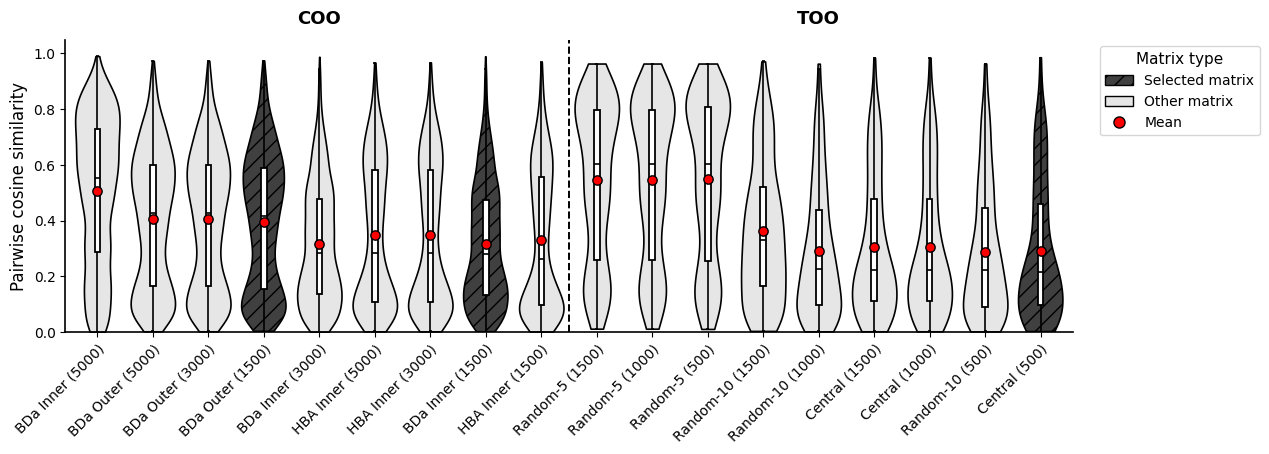

Saved editable SVG to: Results_Cosine_Similarity/Violin_COO_TOO_pairwise_cosine_similarity_editable.svg


In [14]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re

# -----------------------------
# Publication-style settings
# -----------------------------
rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.title_fontsize": 11,
    "legend.fontsize": 10,

    # Keep text editable in Adobe Illustrator
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

output_dir = "Matrix-Similarity/Results_Cosine_Similarity"
os.makedirs(output_dir, exist_ok=True)

# Use explicit hexadecimal colours for more reliable SVG handling
SELECTED_COLOR = "#404040"   # dark grey
OTHER_COLOR = "#E6E6E6"      # light grey
MEAN_DOT_SIZE = 45

# -----------------------------
# Order COO then TOO, each ranked by median
# -----------------------------
median_order = (
    plot_df
    .groupby(["group", "matrix_short"])["pairwise_cosine_similarity"]
    .median()
    .reset_index()
)

coo_order = (
    median_order[median_order["group"] == "COO"]
    .sort_values("pairwise_cosine_similarity", ascending=False)
    ["matrix_short"]
    .tolist()
)

too_order = (
    median_order[median_order["group"] == "TOO"]
    .sort_values("pairwise_cosine_similarity", ascending=False)
    ["matrix_short"]
    .tolist()
)

order = coo_order + too_order

def format_matrix_label(matrix_name, group):
    """
    Convert internal matrix names into publication-style labels.

    Examples
    --------
    TSP-HBA_Inner_300_1500_10 -> HBA Inner (1500)
    TSP-BDa_Outer_300_1500_10 -> BDa Outer (1500)
    Sampling10_300_1500       -> Random-10 (1500)
    Sampling5_300_1000        -> Random-5 (1000)
    2Median_300_500           -> Central (500)
    """

    cleaned = str(matrix_name)

    # Remove common filename/pipeline prefixes
    for prefix in [
        "CIBERSORTx-Matrix_",
        "CIBERSORTx-TOO-Matrix_",
        "TSP-",
        "TOO_",
        "COO_",
    ]:
        cleaned = cleaned.replace(prefix, "")

    reference_patterns = [
        (r"BDa[_\s-]*Inner", "BDa Inner"),
        (r"BDa[_\s-]*Outer", "BDa Outer"),
        (r"HBA[_\s-]*Inner", "HBA Inner"),
        (r"HBA[_\s-]*Outer", "HBA Outer"),
        (r"Sampling[_\s-]*10", "Random-10"),
        (r"Sampling[_\s-]*5", "Random-5"),
        (r"2Median", "Central"),
    ]

    reference = None

    for pattern, label in reference_patterns:
        if re.search(pattern, cleaned, flags=re.IGNORECASE):
            reference = label
            break

    # Fallback for an unrecognised reference name
    if reference is None:
        reference = re.split(r"__|_\d", cleaned)[0]
        reference = (
            reference
            .replace("_", " ")
            .replace("-", " ")
            .strip()
        )

    # Extract numeric parameters
    numbers = [
        int(value)
        for value in re.findall(
            r"(?<![A-Za-z])\d+(?![A-Za-z])",
            cleaned
        )
    ]

    max_signatures = None

    if group == "COO":
        if len(numbers) >= 2:
            max_signatures = numbers[1]

    elif group == "TOO":
        # TOO convention:
        # minimum_maximum
        if numbers:
            max_signatures = numbers[-1]

    if max_signatures is None:
        return reference

    return f"{reference} ({max_signatures})"

display_label_map = {
    matrix: format_matrix_label(matrix, "COO")
    for matrix in coo_order
}

display_label_map.update({
    matrix: format_matrix_label(matrix, "TOO")
    for matrix in too_order
})

display_labels = [
    display_label_map[matrix]
    for matrix in order
]

palette_map = {
    matrix: SELECTED_COLOR if matrix in highlight_matrices else OTHER_COLOR
    for matrix in order
}

print(
    plot_df["pairwise_cosine_similarity"].min(),
    plot_df["pairwise_cosine_similarity"].max()
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 3.8))

# Record the current number of collections so that only the violin bodies
# are modified later.
collections_before = len(ax.collections)

sns.violinplot(
    data=plot_df,
    x="matrix_short",
    y="pairwise_cosine_similarity",
    order=order,
    palette=palette_map,
    inner=None,
    density_norm="width",
    width=0.80,
    cut=0,
    linewidth=1.2,
    saturation=1,
    ax=ax
)

# Capture only the collections created by violinplot
violin_bodies = list(ax.collections[collections_before:])

label_to_x = {
    label: index
    for index, label in enumerate(order)
}

selected_x = {
    label_to_x[label]
    for label in highlight_matrices
    if label in label_to_x
}

# Apply explicit fills, full opacity, and black outlines only to violin bodies
for body in violin_bodies:
    try:
        vertices = body.get_paths()[0].vertices
    except (IndexError, AttributeError):
        continue

    xpos = int(round(vertices[:, 0].mean()))

    body.set_edgecolor("#000000")
    body.set_linewidth(1.2)
    body.set_alpha(1.0)

    if xpos in selected_x:
        body.set_facecolor(SELECTED_COLOR)

        # Remove this line if Illustrator still has problems with hatching
        body.set_hatch("//")
    else:
        body.set_facecolor(OTHER_COLOR)
        body.set_hatch(None)

# Add boxplots after recolouring the violin bodies
sns.boxplot(
    data=plot_df,
    x="matrix_short",
    y="pairwise_cosine_similarity",
    order=order,
    width=0.10,
    showcaps=True,
    showfliers=False,
    zorder=3,
    boxprops={
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.3
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.2
    },
    capprops={
        "color": "black",
        "linewidth": 1.2
    },
    medianprops={
        "color": "black",
        "linewidth": 2.0
    },
    ax=ax
)

# Format and clamp boxplot lines to the valid cosine-similarity range
# Format boxplot lines and clamp any y-values below zero
for line in ax.lines:
    line.set_color("black")
    line.set_linewidth(1.2)
    line.set_solid_capstyle("butt")
    line.set_dash_capstyle("butt")

    ydata = np.asarray(line.get_ydata(), dtype=float)

    if ydata.size:
        line.set_ydata(np.maximum(ydata, 0.0))

    line.set_clip_on(True)
    line.set_clip_path(ax.patch)

for patch in ax.patches:
    patch.set_clip_on(True)
    patch.set_clip_path(ax.patch)

ax.set_ylim(0, 1.05)

# Separator between COO and TOO
ax.axvline(
    x=len(coo_order) - 0.5,
    color="black",
    linestyle="--",
    linewidth=1.4
)

# Group labels
ax.text(
    (len(coo_order) - 1) / 2,
    1.04,
    "COO",
    ha="center",
    va="bottom",
    transform=ax.get_xaxis_transform(),
    fontsize=13,
    fontweight="bold"
)

ax.text(
    len(coo_order) + (len(too_order) - 1) / 2,
    1.04,
    "TOO",
    ha="center",
    va="bottom",
    transform=ax.get_xaxis_transform(),
    fontsize=13,
    fontweight="bold"
)

# Mean dots
means = (
    plot_df
    .groupby("matrix_short")["pairwise_cosine_similarity"]
    .mean()
)

for xpos, label in enumerate(order):
    if label in means:
        ax.scatter(
            xpos,
            means[label],
            color="red",
            s=MEAN_DOT_SIZE,
            zorder=4,
            marker="o",
            edgecolor="black"
        )

# Labels
ax.set_xlabel("")
ax.set_ylabel("Pairwise cosine similarity")
ax.set_ylim(0, 1.05)
ax.margins(x=0.01, y=0)

# Clip violin fills and outlines exactly to the plotting area
for body in violin_bodies:
    body.set_clip_on(True)
    body.set_clip_path(ax.patch)

ax.spines["bottom"].set_zorder(10)

ax.set_xticks(range(len(order)))

ax.set_xticklabels(
    display_labels,
    rotation=45,
    ha="right",
    rotation_mode="anchor",
    fontsize=10
)

# Legend
legend_handles = [
    Patch(
        facecolor=SELECTED_COLOR,
        edgecolor="black",
        hatch="//",
        label="Selected matrix"
    ),
    Patch(
        facecolor=OTHER_COLOR,
        edgecolor="black",
        label="Other matrix"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="red",
        label="Mean",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=8,
        linestyle=""
    )
]

ax.legend(
    handles=legend_handles,
    title="Matrix type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

# Stronger axes
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

sns.despine(ax=ax)

# -----------------------------
# Save editable vector output
# -----------------------------
svg_out = os.path.join(
    output_dir,
    "Violin_COO_TOO_pairwise_cosine_similarity_editable.svg"
)

fig.savefig(
    svg_out,
    format="svg",
    bbox_inches="tight",
    facecolor="white",
    transparent=False
)

plt.show()

print(f"Saved editable SVG to: {svg_out}")
